In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

import warnings
warnings.filterwarnings('ignore') 

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# read data
data = pd.read_csv('MS_categ_id_hddm_stim.csv')
data

,subj_idx,val,id,stim,response,rt
0,7304,Good,Self,1,1,0.4236
1,7304,Bad,Other,0,0,0.5631
2,7304,Bad,Self,1,1,0.7198
3,7304,Good,Other,0,0,0.6799
4,7304,Good,Self,1,1,0.3560
...,...,...,...,...,...,...
14488,7345,Good,Other,0,0,0.3472
14489,7345,Bad,Self,1,1,0.4249
14490,7345,Bad,Self,1,1,0.3351
14491,7345,Bad,Other,0,0,0.4232


In [3]:
hddm_id_acc = hddm.load('hddm_id_m0_acc.hddm')
hddm_id_choice = hddm.load('hddm_id_m1_choice.hddm')
Stim_zflip = hddm.load('hddmStim_zflip_m1.hddm')
Stim_vflip = hddm.load('hddmStim_vflip_m1.hddm')
Reg_id_acc = hddm.load('hddmReg_id_m0_acc.hddm')
Reg_id_choice = hddm.load('hddmReg_id_m2_choice.hddm')
Reg_vflip_coef = hddm.load('hddmReg_stim_vflip_m2.hddm')
Reg_vflip_link = hddm.load('hddmReg_stim_vflip_m3.hddm')
Reg_zflip = hddm.load('hddmReg_stim_zflip_m2.hddm')

In [4]:
ppc_data_hddm_id_choice = hddm.utils.post_pred_gen(hddm_id_choice, progress_bar=True)
ppc_data_hddm_id_acc = hddm.utils.post_pred_gen(hddm_id_acc, progress_bar=True)
ppc_data_Stim_dc = hddm.utils.post_pred_gen(Stim_vflip, progress_bar=True)
ppc_data_Stim_zflip = hddm.utils.post_pred_gen(Stim_zflip)
ppc_data_Reg_id_acc = hddm.utils.post_pred_gen(Reg_id_acc, progress_bar=True)

Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...


In [6]:
ppc_data_Reg_id_choice = hddm.utils.post_pred_gen(Reg_id_choice, progress_bar=True)
ppc_data_Reg_vflip_coef = hddm.utils.post_pred_gen(Reg_vflip_coef, progress_bar=True)
ppc_data_Reg_vflip_link = hddm.utils.post_pred_gen(Reg_vflip_link, progress_bar=True)
ppc_data_Reg_zflip = hddm.utils.post_pred_gen(Reg_zflip, progress_bar=True)

Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...


In [8]:
# ====================== Save all PPC data locally ======================
import pickle

# Store all PPC data in a dictionary for saving
ppc_all_data = {
    "ppc_data_hddm_id_choice": ppc_data_hddm_id_choice,
    "ppc_data_hddm_id_acc": ppc_data_hddm_id_acc,
    "ppc_data_Stim_dc": ppc_data_Stim_dc,
    "ppc_data_Stim_zflip": ppc_data_Stim_zflip,
    "ppc_data_Reg_id_acc": ppc_data_Reg_id_acc,
    "ppc_data_Reg_id_choice": ppc_data_Reg_id_choice,
    "ppc_data_Reg_dc": ppc_data_Reg_vflip_coef,
    "ppc_data_Reg_vflip": ppc_data_Reg_vflip_link,
    "ppc_data_Reg_zflip": ppc_data_Reg_zflip,
}

# Save to file (file name: all_ppc_data.pkl)
with open("all_ppc_data.pkl", "wb") as f:
    pickle.dump(ppc_all_data, f)

print("All PPC data has been saved locally: all_ppc_data.pkl")

All PPC data has been saved locally: all_ppc_data.pkl


In [13]:
def ppc_mean_with_choice(ppc_data, obs_data):
    """
    Compute mean values across posterior draws for each trial
    and derive predicted choice based on model response and true stimulus.
    
    Output:
    Trial-level averaged PPC data with derived predicted choice.
    
    Logic:
    response = model accuracy (correct/incorrect)
    stim = true target value
    -> Derive predicted choice accordingly
    """
    # ======================
    #  Compute trial-level means from PPC data
    # ======================
    ppc_df = ppc_data.reset_index()
    ppc_df["rt_abs"] = ppc_df["rt"].abs()
    ppc_trial_mean = ppc_df.groupby("trial_idx").sample(1).reset_index(drop=True)
    ppc_trial_mean = ppc_trial_mean.rename(columns={
        "rt_abs": "rt_mean",
        "response": "response_mean"
    })

    #ppc_trial_mean = ppc_df.groupby("trial_idx").apply(lambda x: x.sample(1)).reset_index(drop=True)
    # # ppc_trial_mean = ppc_df.groupby("trial_idx")[["rt_abs", "response"]].mean().reset_index()
    # ppc_trial_mean.columns = ["trial_idx", "rt_mean", "response_mean"]

    # ======================
    #  Merge with observed data to get trial metadata
    # ======================
    obs_idx = obs_data.reset_index(drop=True).reset_index().rename(columns={"index": "trial_idx"})
    merged = ppc_trial_mean.merge(
      obs_idx[["trial_idx", "subj_idx", "id", "val", "stim"]],
      on="trial_idx",
      how="left"
  )

    # ======================
    #  Derive predicted accuracy and final choice
    # ======================
    merged["pred_correct"] = (merged["response_mean"] > 0.5).astype(int)
    
    # Derive predicted choice
    merged["pred_choice"] = np.where(
        merged["pred_correct"] == 1,
        merged["stim"],           # Correct prediction: match true stimulus
        1 - merged["stim"]        # Incorrect prediction: choose opposite stimulus
    )

    # ======================
    # Return cleaned output dataframe
    # ======================
    final_ppc = merged[["subj_idx", "trial_idx", "subj_idx", "id", "val", "stim", "rt_mean", "response_mean", "pred_choice"]].copy()

    return final_ppc

In [22]:
ppc_trans_data_hddm_id_choice = ppc_mean_with_choice(ppc_data_hddm_id_choice, data)
ppc_trans_data_hddm_id_acc = ppc_mean_with_choice(ppc_data_hddm_id_acc, data)
ppc_trans_data_Stim_dc = ppc_mean_with_choice(ppc_data_Stim_dc, data)
ppc_trans_data_Stim_zflip = ppc_mean_with_choice(ppc_data_Stim_zflip, data)
ppc_trans_data_Reg_id_acc = ppc_mean_with_choice(ppc_data_Reg_id_acc, data)
ppc_trans_data_Reg_id_choice = ppc_mean_with_choice(ppc_data_Reg_id_choice, data)
ppc_trans_data_Reg_vflip_coef = ppc_mean_with_choice(ppc_data_Reg_vflip_coef, data)
ppc_trans_data_Reg_vflip_link = ppc_mean_with_choice(ppc_data_Reg_vflip_link, data)
ppc_trans_data_Reg_zflip = ppc_mean_with_choice(ppc_data_Reg_zflip, data)

In [20]:
def plot_crf_2_conditions(
    real_data,
    model_ppc_dict,
    quantiles=[0, 0.25, 0.5, 0.75, 1]
):
    plt.rcParams.update({'font.size': 13})

    plot_config = [
        {"id": "Self",   "target": 1, "title": "Self Trials"},
        {"id": "Other",  "target": 1, "title": "Other Trials"},
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
              "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

    for ax_idx, config in enumerate(plot_config):
        ax = axes[ax_idx]
        cond = config["id"]
        target = config["target"]
        title = config["title"]

        def plot_curve(df, rt_col, choice_col, label, color, ls="-", lw=2):
            try:
                df_cond = df[df["id"] == cond].copy()
                df_cond["rt_bin"] = pd.qcut(df_cond[rt_col], quantiles, labels=False, duplicates="drop")
                grp = df_cond.groupby("rt_bin").agg(
                    rt=(rt_col, "mean"),
                    prob=(choice_col, lambda x: (x == target).mean())
                ).reset_index()
                ax.plot(grp["rt"], grp["prob"], label=label, color=color,
                        linestyle=ls, linewidth=lw, marker="o", markersize=5)
            except:
                pass

        plot_curve(real_data, "rt", "response", "Real Data", "black", ls="--", lw=3)
        for i, (model_name, model_df) in enumerate(model_ppc_dict.items()):
            plot_curve(model_df, "rt_mean", "pred_choice", model_name, colors[i % len(colors)], lw=1.8)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)

        ax.set_xlabel("Reaction Time (s)", fontsize=16, labelpad=8)
        ax.set_ylabel("Probability of choosing Self", fontsize=16, labelpad=8)
        ax.set_title(title, fontsize=17, pad=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.1, 0.5),
               fontsize=14, frameon=False)

    plt.tight_layout()
    return fig

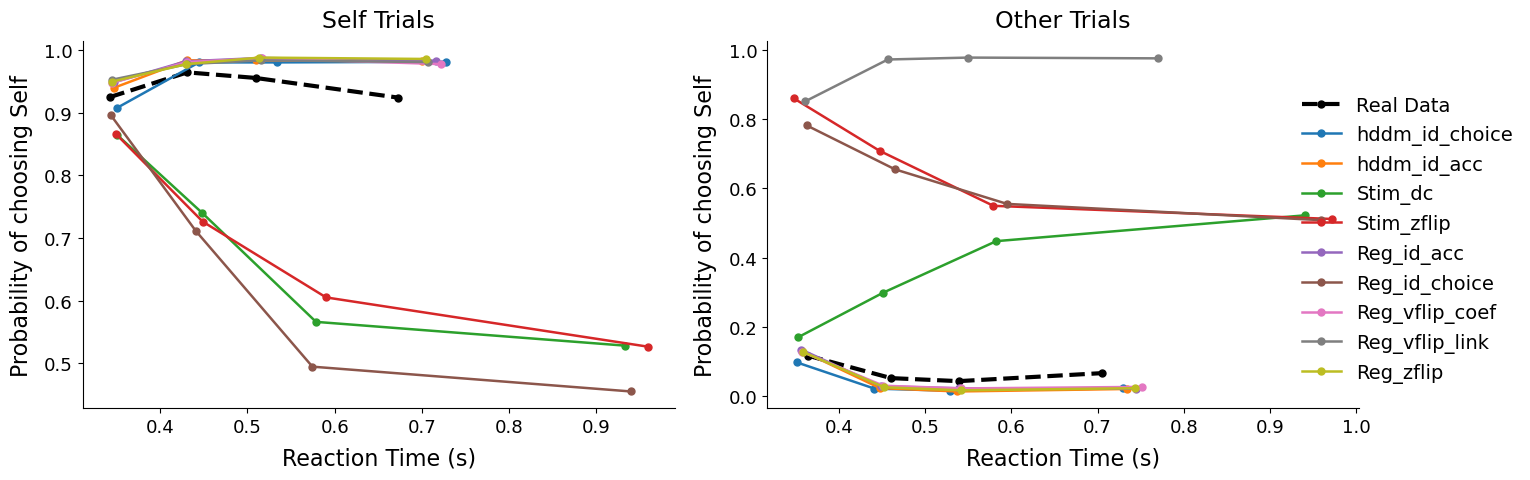

In [23]:
model_ppc_data = {
    "hddm_id_choice": ppc_trans_data_hddm_id_choice,
    "hddm_id_acc":    ppc_trans_data_hddm_id_acc,
    "Stim_dc":     ppc_trans_data_Stim_dc,
    "Stim_zflip":  ppc_trans_data_Stim_zflip,
    "Reg_id_acc":     ppc_trans_data_Reg_id_acc,
    "Reg_id_choice":  ppc_trans_data_Reg_id_choice,
    "Reg_vflip_coef":      ppc_trans_data_Reg_vflip_coef,
    "Reg_vflip_link":   ppc_trans_data_Reg_vflip_link,
    "Reg_zflip":   ppc_trans_data_Reg_zflip,
}


fig = plot_crf_2_conditions(
    real_data=data,
    model_ppc_dict=model_ppc_data
)

plt.show()
fig.savefig("CRF_model_comparison.svg", format="svg", bbox_inches="tight", dpi=300)

Plotting: hddm_id_choice
Plotting: hddm_id_acc
Plotting: Stim_vflip
Plotting: Stim_zflip
Plotting: Reg_id_acc
Plotting: Reg_id_choice
Plotting: Reg_vflip_coef
Plotting: Reg_vflip_link
Plotting: Reg_zflip


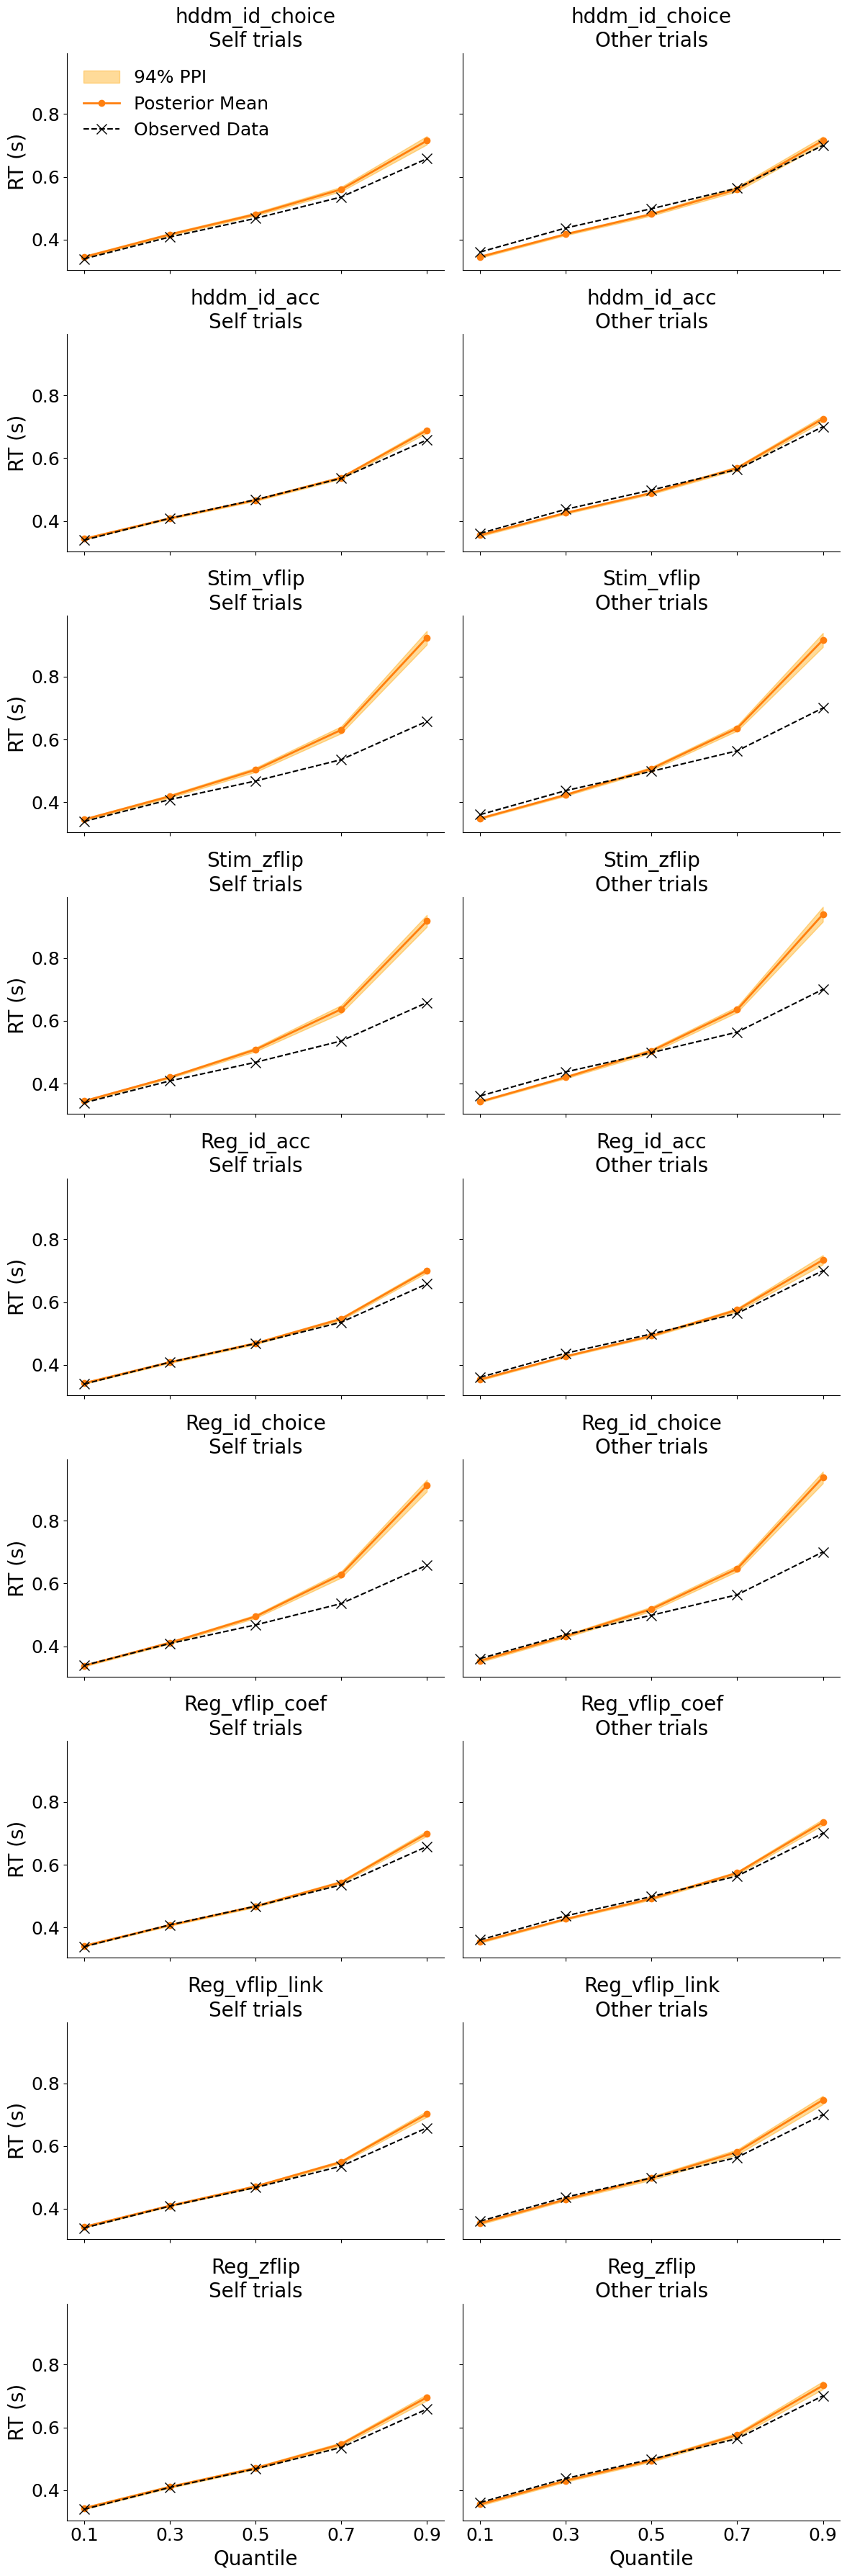

In [25]:
ppc_dict = {
    "hddm_id_choice":  ppc_data_hddm_id_choice,
    "hddm_id_acc":     ppc_data_hddm_id_acc,
    "Stim_vflip":      ppc_data_Stim_dc,
    "Stim_zflip":      ppc_data_Stim_zflip,
    "Reg_id_acc":      ppc_data_Reg_id_acc,
    "Reg_id_choice":   ppc_data_Reg_id_choice,
    "Reg_vflip_coef":  ppc_data_Reg_vflip_coef,
    "Reg_vflip_link":  ppc_data_Reg_vflip_link,
    "Reg_zflip":       ppc_data_Reg_zflip,
}


def plot_all_models_from_ppc(ppc_dict, obs_data, quantiles=[0.1, 0.3, 0.5, 0.7, 0.9]):
    plt.rcParams.update({'font.size': 14})

    model_list = list(ppc_dict.items())
    conditions = ["Self", "Other"]

    n_models = len(model_list)
    n_cols = len(conditions)
    fig, axes = plt.subplots(n_models, n_cols, figsize=(12, 4 * n_models), sharex=True, sharey=True)

    if n_models == 1:
        axes = np.array([axes])

    for model_row, (model_name, ppc) in enumerate(model_list):
        print(f"Plotting: {model_name}")

        ppc_df = ppc.reset_index()
        obs_data_reset = obs_data.reset_index(drop=True).reset_index().rename(columns={"index": "trial_idx"})
        ppc_df = ppc_df.merge(obs_data_reset[["trial_idx", "id"]], on="trial_idx", how="left")

        for col, cond in enumerate(conditions):
            ax = axes[model_row, col]

            # 观测数据:该 id 条件下所有试次的 RT 分位数
            obs_q = obs_data.loc[obs_data["id"] == cond, "rt"].quantile(quantiles)

            # 模型预测:该 id 条件下所有试次的 RT 绝对值分位数
            pp_sub = ppc_df[ppc_df["id"] == cond]
            pp_qs = []
            for draw in pp_sub["draw"].unique():
                vals = pp_sub[pp_sub["draw"] == draw]["rt"].abs()
                if len(vals) >= 3:
                    pp_qs.append(vals.quantile(quantiles).values)

            pp_qs = np.array(pp_qs)
            m = pp_qs.mean(axis=0)
            lo = np.percentile(pp_qs, 3, axis=0)
            hi = np.percentile(pp_qs, 97, axis=0)

            ax.fill_between(quantiles, lo, hi, color="orange", alpha=0.4, label="94% PPI")
            ax.plot(quantiles, m, "o-", color="C1", lw=2, label="Posterior Mean")
            ax.plot(quantiles, obs_q, "kx--", ms=10, label="Observed Data")

            ax.set_title(f"{model_name}\n{cond} trials", fontsize=20)
            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='both', labelsize=18)

            if model_row == n_models - 1:
                ax.set_xlabel("Quantile", fontsize=20)
                ax.set_xticks(quantiles)
            if col == 0:
                ax.set_ylabel("RT (s)", fontsize=20)

    axes[0, 0].legend(loc="upper left", fontsize=18, frameon=False)
    plt.tight_layout()
    return fig

fig = plot_all_models_from_ppc(ppc_dict=ppc_dict, obs_data=data)

fig.savefig("9_models_ppc.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()